# **Exploratory Data Analysis**

This notebook focuses on exploratory analysis of the processed MetroPT and hydraulic datasets. The goal is to identify important sensor patterns, understand variable relationships, and examine how different operating or degradation states are reflected in the available measurements.

Unlike Notebook 01, which focused on data loading and preprocessing, this notebook investigates the structure, variability, and relationships within the processed data in order to support later statistical testing and interpretation. Each dataset is analyzed separately, followed by a conceptual comparison between the two fluid-power systems.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

metro = pd.read_csv('../data/processed/metro_cleaned.csv', parse_dates=['timestamp'])
hydraulics = pd.read_csv('../data/processed/hydraulics_features.csv')

print(f"MetroPT-3 dataset shape: {metro.shape}")
print(f"Hydraulic feature dataset shape: {hydraulics.shape}")

MetroPT-3 dataset shape: (1516948, 16)
Hydraulic feature dataset shape: (2205, 73)


## Analysis Roadmap

### MetroPT-3 Analysis
- Continuous sensor distributions
- Correlation structure
- Temporal patterns
- Binary/state signal frequencies
- Sensor behavior by operating state

### Hydraulic System Analysis
- Feature distributions
- Correlation structure
- Condition-stratified analysis
- Stable vs unstable cycles

### Cross-Dataset Comparison
- Structural properties
- Common sensor concepts
- Key differences

## MetroPT-3 Analysis

### Continuous sensor distributions

The seven continuous sensors measure pressure, temperature, and motor current on the air compressor. Their distributions reveal the typical operating ranges and suggest whether sensor values are concentrated around a baseline or spread across a wider dynamic range.

In [18]:
continuous_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']

Grouping by physical quantity type (pressure vs temperature/current):

#### Pressure-related sensors

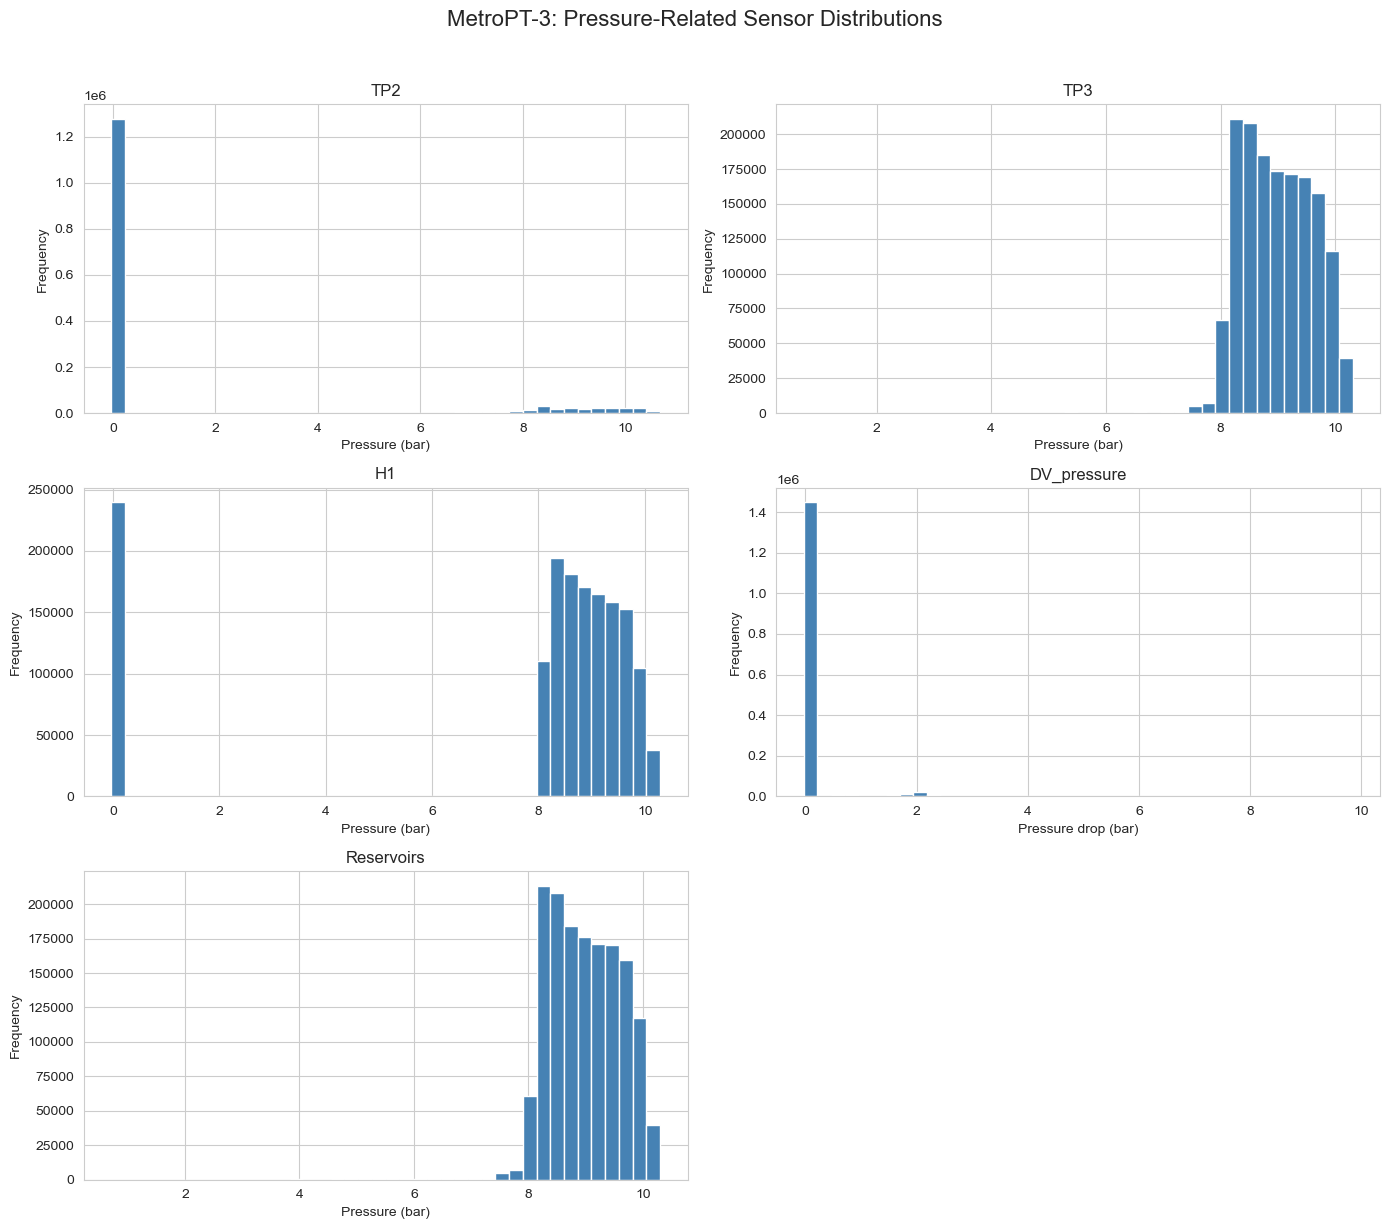

In [16]:
pressure_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(pressure_cols):
    axes[i].hist(metro[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Pressure (bar)' if col != 'DV_pressure' else 'Pressure drop (bar)')
    axes[i].set_ylabel('Frequency')

for j in range(len(pressure_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('MetroPT-3: Pressure-Related Sensor Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Observations**

`TP3` and `Reservoirs` have very similar distributions, concentrated mostly between about 8 and 10 bar. This is consistent with the dataset description, which states that downstream reservoir pressure should be close to the pneumatic panel pressure.

`TP2`, `H1`, and `DV_pressure` show strong mass near zero, together with a separate operating range at higher values. This suggests that these sensors are influenced by different machine states, rather than following one single continuous regime.

`DV_pressure` is especially sparse away from zero, which is consistent with the documentation that near-zero values indicate compressor operation under load.

Because `TP2`, `H1`, and `DV_pressure` contain a large mass of values near zero, their full histograms compress the active operating range and make it difficult to read. To visualize the non-zero behavior more clearly, values below 0.1 are filtered out in the plots below.

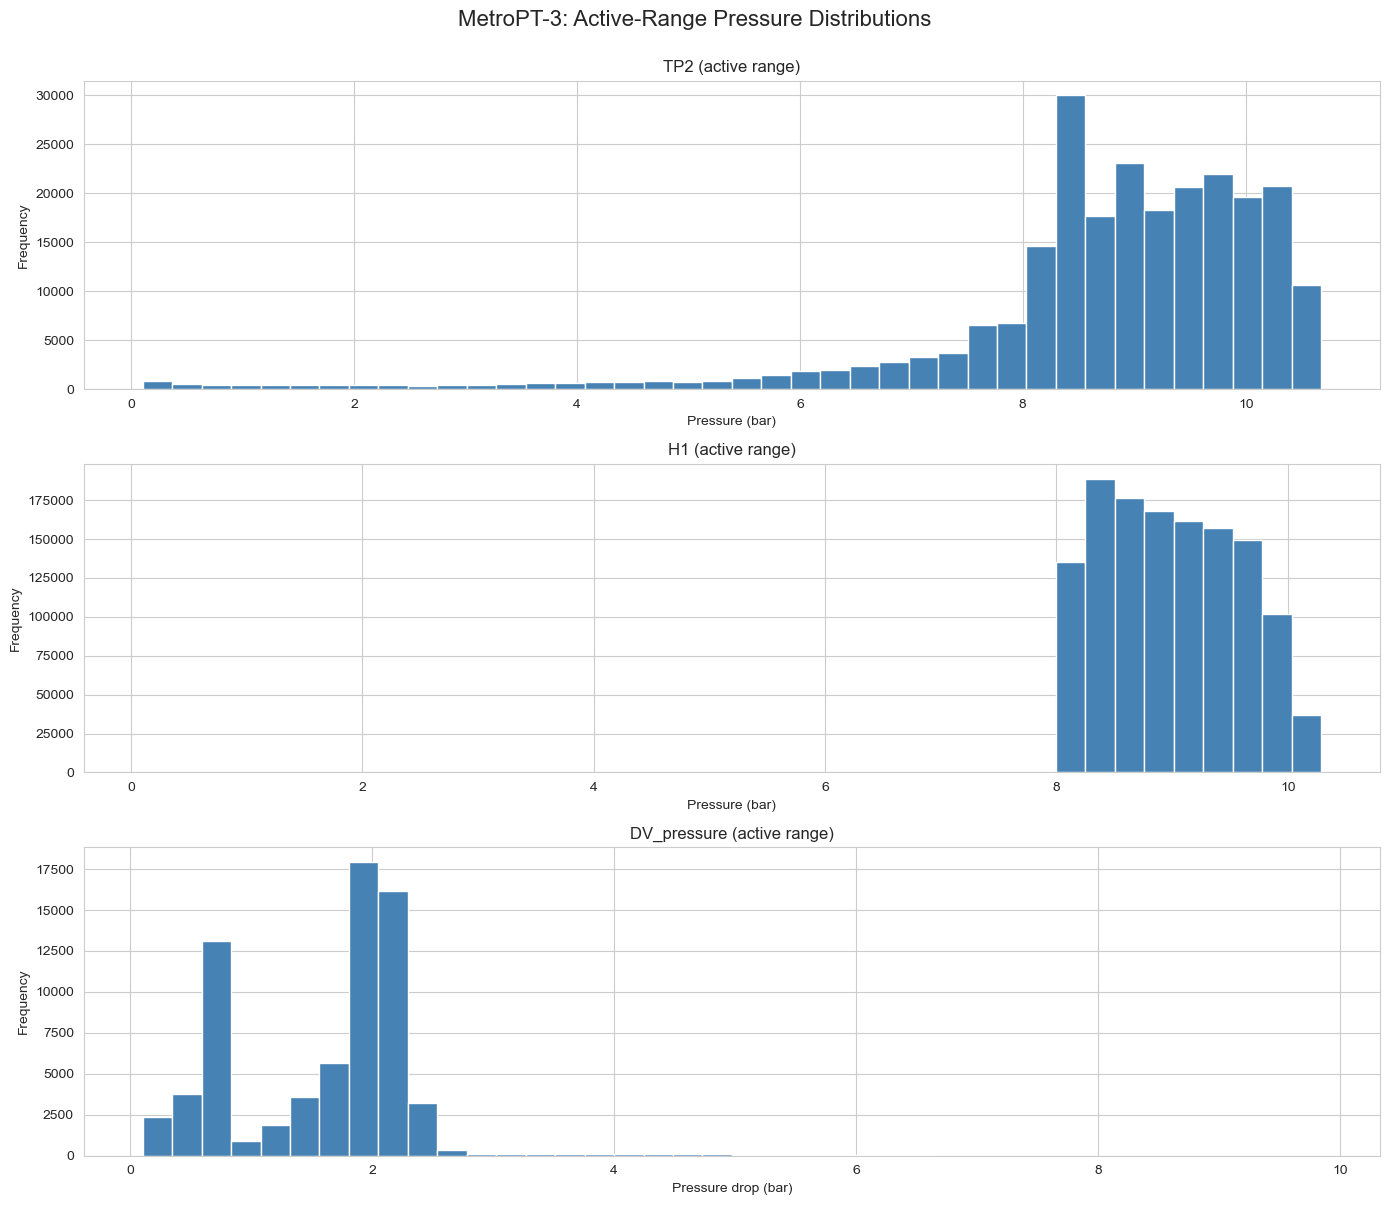

In [31]:
active_pressure_cols = ['TP2', 'H1', 'DV_pressure']

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for i, col in enumerate(active_pressure_cols):
    active_values = metro.loc[metro[col] > 0.1, col]
    axes[i].hist(active_values, bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} (active range)')
    axes[i].set_xlabel('Pressure (bar)' if col != 'DV_pressure' else 'Pressure drop (bar)')
    axes[i].set_ylabel('Frequency')

fig.suptitle('MetroPT-3: Active-Range Pressure Distributions', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

**Observations**

`TP2` (active range) has a broad active distribution, with most values concentrated roughly between 8 and 10.5 bar, but also a long lower-pressure tail. That suggests `TP2` reflects a wider range of active compressor states than `H1`.

`H1` (active range) is much more concentrated in the high-pressure region, mostly around 8–10 bar, with a relatively compact shape compared with `TP2`. That suggests a more stable active operating range.

`DV_pressure` (active range) is clearly different from the others. Its active values are concentrated mostly between about 0.5 and 2.5 bar, with a multi-peaked structure and a much smaller range than the other pressure variables. That suggests a different operational role and stronger dependence on specific machine states or events.

#### Temperature and motor current sensors

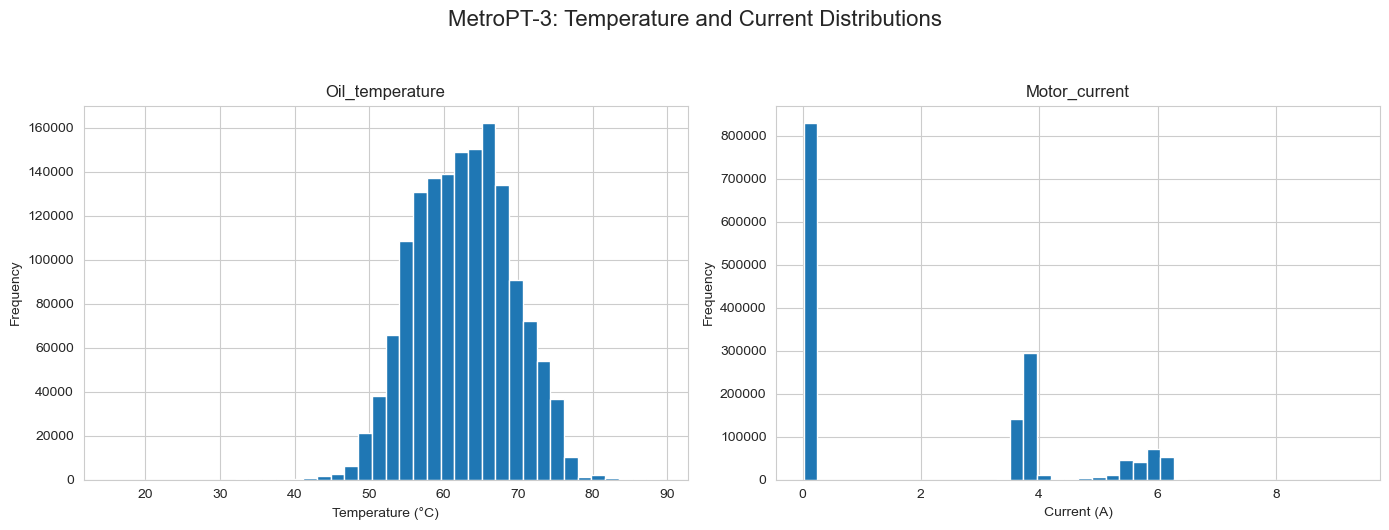

In [15]:
other_cols = ['Oil_temperature', 'Motor_current']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(metro['Oil_temperature'], bins=40)
axes[0].set_title('Oil_temperature')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')

axes[1].hist(metro['Motor_current'], bins=40)
axes[1].set_title('Motor_current')
axes[1].set_xlabel('Current (A)')
axes[1].set_ylabel('Frequency')

fig.suptitle('MetroPT-3: Temperature and Current Distributions', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

**Observations**

`Oil_temperature` is approximately symmetric and centered around 62°C, reflecting stable thermal conditions during operation. 

`Motor_current` shows a strongly multi-modal distribution, with a dominant inactive region near 0 A and additional operating clusters around roughly 4 A and 5–6 A. This is broadly consistent with the documented compressor operating modes. The 9 A peak may be too small to visually pick out at this bin count. Let's check it:

In [33]:
print(metro['Motor_current'].describe())
print((metro['Motor_current'] > 7).sum(), "samples above 7 A")

count    1.516948e+06
mean     2.050171e+00
std      2.302053e+00
min      2.000000e-02
25%      4.000000e-02
50%      4.500000e-02
75%      3.807500e+00
max      9.295000e+00
Name: Motor_current, dtype: float64
111 samples above 7 A


Seems values above 7 A appear only rarely and likely correspond to short startup-related events. This confirms `Motor_current` as a strong indicator of the compressor operating state: mostly idle, with brief active phases and rare startup peaks.

### Correlation structure

After examining the distributions of the continuous MetroPT variables, the next step is to study how these measurements relate to one another. For this purpose, Pearson correlation is used as a first summary of linear dependence between pairs of continuous sensor variables.

The Pearson correlation coefficient between two variables $X$ and $Y$ is defined as:

$$r_{X,Y} = \frac{\operatorname{Cov}(X,Y)}{\sigma_X \sigma_Y}$$

It takes values between $-1$ and $1$, where values close to $1$ indicate a strong positive linear relationship, values close to $-1$ indicate a strong negative linear relationship, and values near $0$ suggest little or no linear association.

Pearson correlation is appropriate here because the MetroPT continuous sensors measure related physical quantities such as pressure, temperature, and motor current, and the goal is to identify variables that move together during compressor operation. It should still be interpreted carefully: correlation reflects association rather than causation and mainly captures linear relationships.

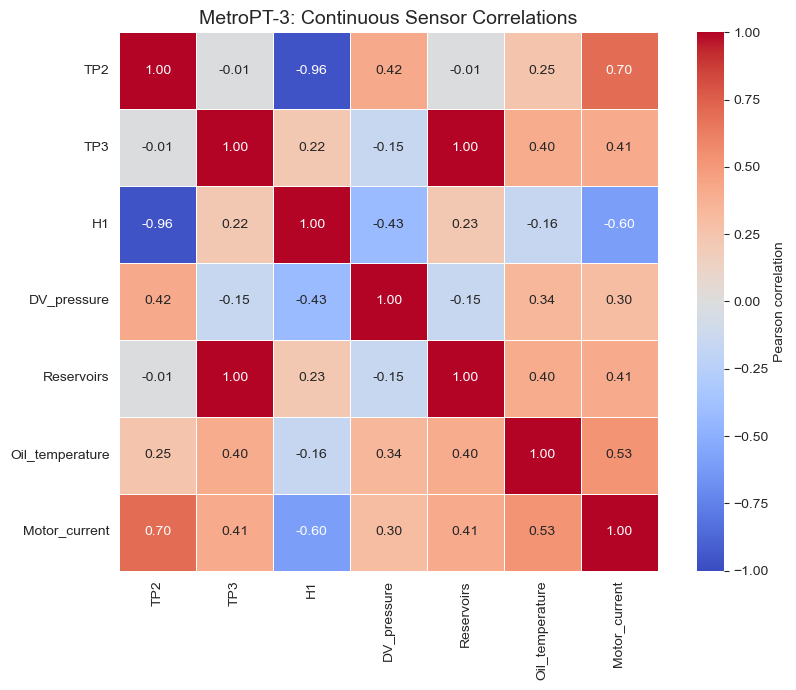

In [36]:
corr = metro[continuous_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'},
    ax=ax
)
ax.set_title('MetroPT-3: Continuous Sensor Correlations', fontsize=14)
plt.tight_layout()
plt.show()

**Observations**

The correlation structure reveals several meaningful patterns that are consistent with the physical behavior of the compressor system.

`TP3` and `Reservoirs` show an almost perfect positive correlation ($r \approx 1.00$), which agrees with the dataset documentation stating that reservoir pressure should remain close to the pneumatic panel pressure. In practice, these two variables appear to capture nearly the same downstream pressure regime.

`TP2` and `H1` are very strongly negatively correlated ($r \approx -0.96$). This suggests a tightly coupled inverse relationship between compressor pressure and the pressure-drop-related signal measured by `H1`, likely reflecting different phases of compressor operation.

`TP2` and `Motor_current` show a strong positive correlation ($r \approx 0.70$), while `H1` and `Motor_current` show a moderately strong negative correlation ($r \approx -0.60$). This is consistent with the idea that higher motor current is associated with active compression, during which `TP2` rises and `H1` tends to decrease.

`Oil_temperature` is moderately correlated with `Motor_current` ($r \approx 0.53$), which is consistent with heat generation during compressor activity. Its relationships with the pressure variables are weaker, suggesting that thermal behavior is influenced by operation, but less directly than pressure and current.

`DV_pressure` shows only weak to moderate correlations with the other continuous sensors. This supports the earlier interpretation that it behaves more like a specific discharge- or state-related signal than a direct continuous pressure measurement.

Overall, the correlation matrix suggests that the continuous sensors are strongly shaped by the compressor operating state, with clear grouping between variables related to active compression (`TP2`, `Motor_current`) and variables describing downstream pneumatic conditions (`TP3`, `Reservoirs`).

### Temporal patterns

The MetroPT-3 dataset spans approximately seven months of continuous recording (February to September 2020). To visualize long-term temporal behavior across the full monitoring period, the continuous sensors are aggregated to hourly averages. A 1-minute resolution still produces overly dense plots at the scale of several months, while 1-hour averaging makes the broader operating patterns easier to interpret.

Four sensors are selected for temporal analysis: `TP3`, `Reservoirs`, `Motor_current`, and `Oil_temperature`. Together they cover the main physical domains of the compressor - downstream pressure, electrical activity, and thermal behavior.

In [47]:
temporal_cols = ['TP3', 'Reservoirs', 'Motor_current', 'Oil_temperature']

# Hourly averaging smooths short-term cycling and reveals long-term trends
metro_resampled = (
    metro.set_index('timestamp')[temporal_cols]
    .resample('1h')
    .mean()
    .reset_index()
)

print(f"Resampled points: {len(metro_resampled)}")

Resampled points: 5116


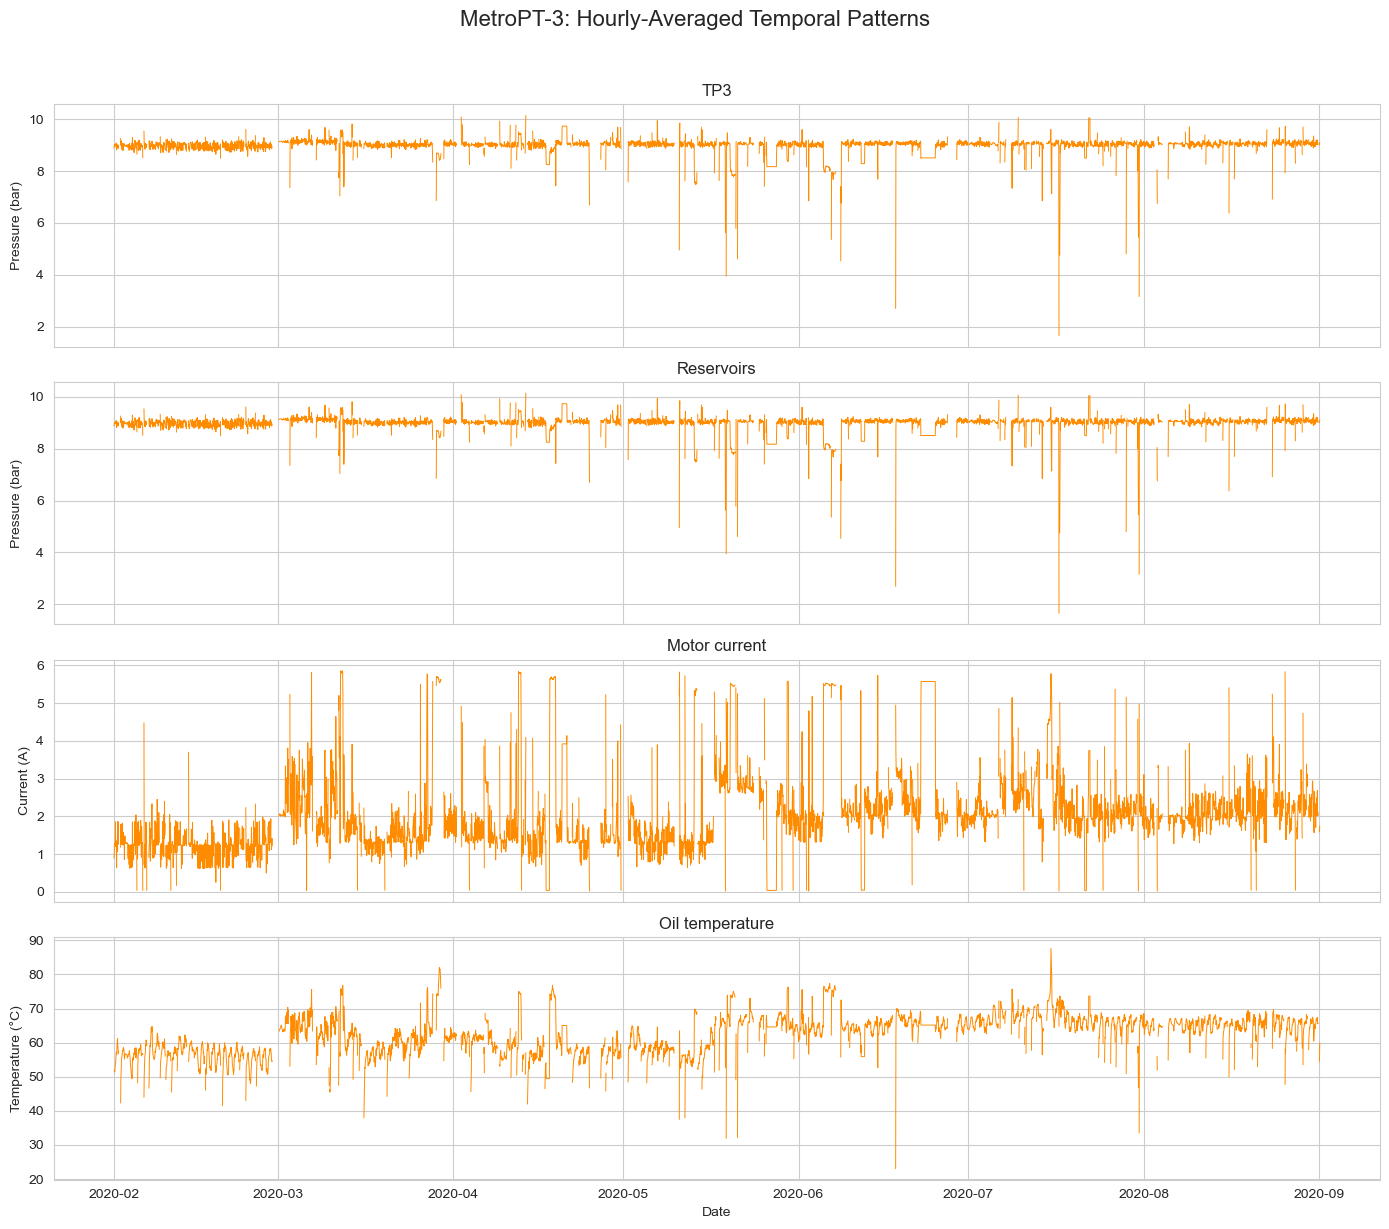

In [51]:
fig, axes = plt.subplots(len(temporal_cols), 1, figsize=(14, 12), sharex=True)

for i, col in enumerate(temporal_cols):
    axes[i].plot(
        metro_resampled['timestamp'],
        metro_resampled[col],
        color='darkorange',
        linewidth=0.7
    )
    axes[i].set_title(title_map[col])
    axes[i].set_ylabel(label_map[col])

axes[-1].set_xlabel('Date')

fig.suptitle('MetroPT-3: Hourly-Averaged Temporal Patterns', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Observations**

The four sensors reveal distinct long-term behaviors across the monitoring period.

`TP3` and `Reservoirs` show nearly identical patterns. Both remain stable around 8–10 bar for most of the recording, with occasional sharp downward spikes that sometimes reach much lower values. This close visual agreement is consistent with the near-perfect correlation observed earlier ($r \approx 1.00$). The pressure drops appear more frequent and deeper in the later part of the monitoring period, especially from May onward, suggesting greater variability in downstream pressure behavior.

`Motor_current` shows a visible change in operating regime around early March. Before this point, the compressor operates at relatively low average current, mostly around 1–2 A, with more limited activity. After March, both the baseline and the peaks become higher, and the signal appears more irregular, with repeated bursts reaching roughly 5–6 A. This suggests a shift toward more demanding or more variable operating conditions.

`Oil_temperature` shows the clearest long-term trend. Starting from a baseline around 55–60°C in February, it gradually moves to higher levels in the following months, while also exhibiting several isolated peaks. Even though the signal later fluctuates, the average thermal regime appears higher in the later part of the monitoring period than at the beginning. This makes oil temperature a plausible candidate for tracking longer-term changes in compressor condition.

A visible discontinuity is also present in late February across several signals. This may reflect downtime, maintenance activity, or another operational interruption, and is therefore relevant for interpretation rather than just a data-quality issue. In an industrial context, such breaks can mark meaningful non-standard operating periods rather than ordinary sensor variation.

Overall, the temporal plots suggest that compressor activity, downstream pressure stability, and thermal behavior are not stationary across the full monitoring period. Several visible shifts (especially the change in motor current regime, the stronger pressure drops in later months, and the higher oil-temperature baseline) are consistent with a system whose operating behavior evolves over time.

### Binary/state signal frequencies

In addition to the continuous sensors, the MetroPT-3 dataset contains several binary (0/1) variables representing operating states, electrical conditions, and alarm-like signals. Their overall frequencies were examined in Notebook 01. Here, the focus shifts from **how often** these signals are active to **when** they are active across the monitoring period.

Five binary signals are selected as especially informative for operational interpretation:

- `COMP` - compressor ON/OFF state
- `DV_eletric` - electric valve activity
- `LPS` - low-pressure switch
- `Pressure_switch` - pressure monitoring signal
- `Caudal_impulses` - airflow pulse signal

To make long-term changes easier to interpret, each signal is transformed into a rolling activation rate, defined as the fraction of time the signal is active within a 1-hour window.

In [52]:
plot_cols = ['COMP', 'DV_eletric', 'LPS', 'Pressure_switch', 'Caudal_impulses']

# Rolling activation rate: fraction of time the signal is active within a 1-hour window
metro_binary = (
    metro.set_index('timestamp')[plot_cols]
    .sort_index()
)

binary_rolling = metro_binary.rolling('1h').mean()

# Hourly resampling for a cleaner long-term view
binary_rolling = binary_rolling.resample('1h').mean().reset_index()

print(f"Rolling activation points: {len(binary_rolling)}")

Rolling activation points: 5116


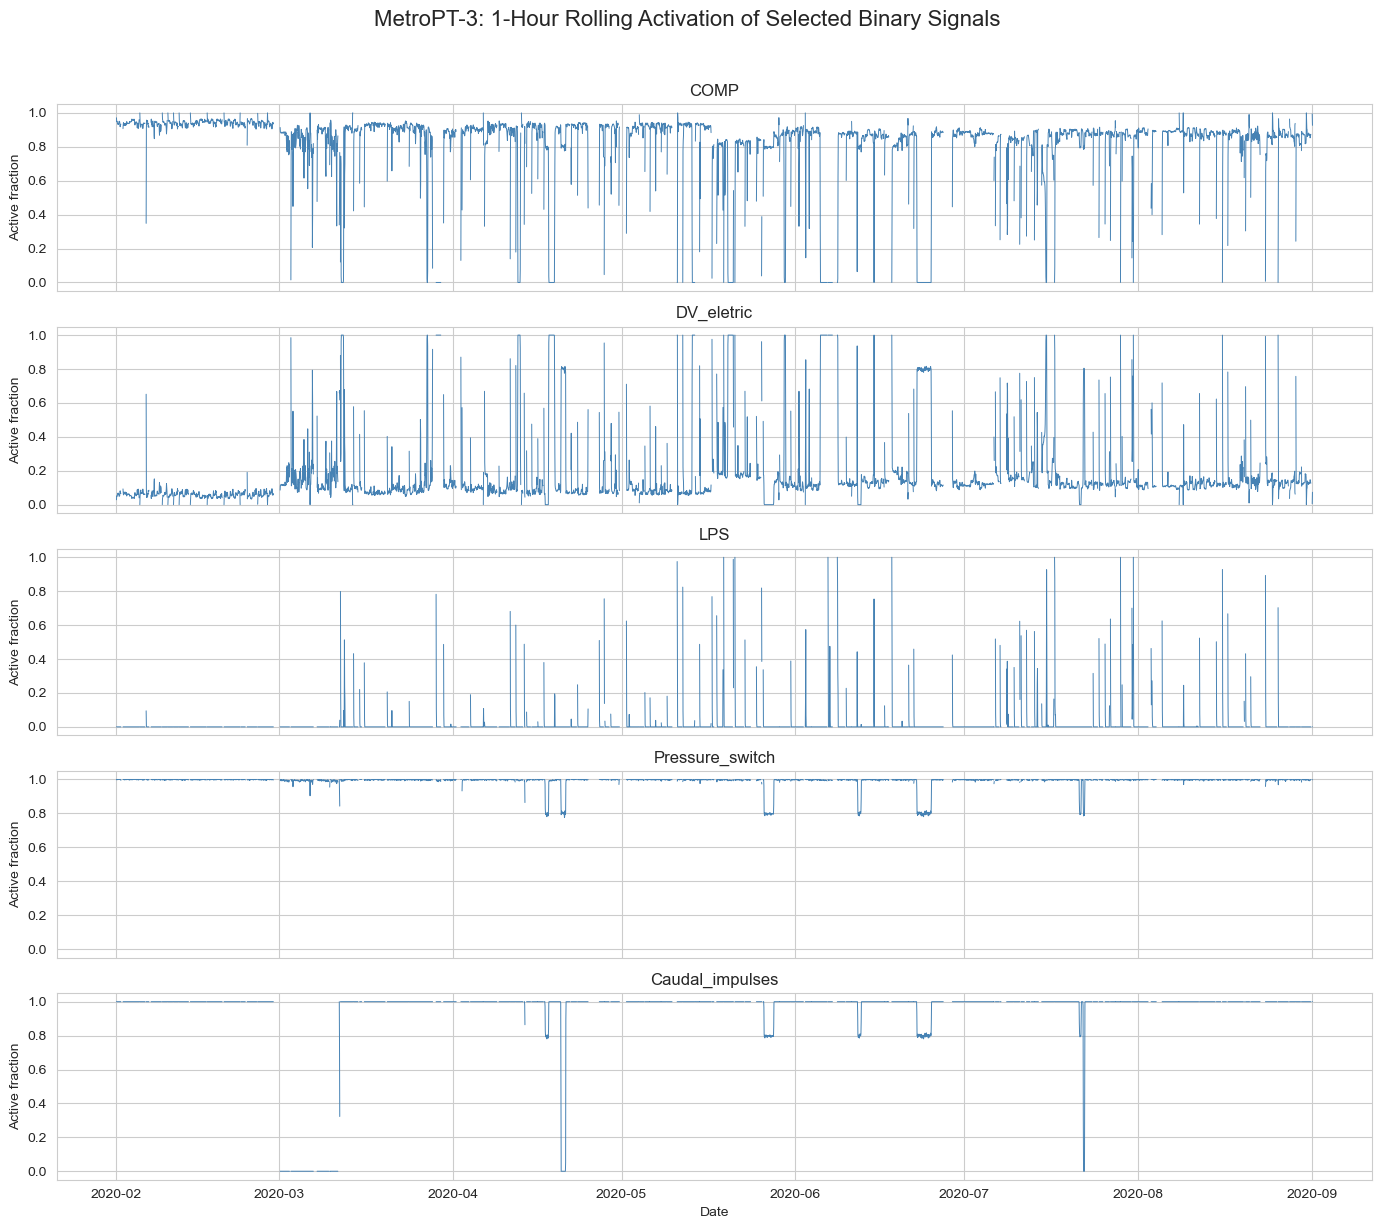

In [56]:
fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 12), sharex=True)

for i, col in enumerate(plot_cols):
    axes[i].plot(
        binary_rolling['timestamp'],
        binary_rolling[col],
        color='steelblue',
        linewidth=0.7
    )
    axes[i].set_title(col)
    axes[i].set_ylabel('Active fraction')
    axes[i].set_ylim(-0.05, 1.05)

axes[-1].set_xlabel('Date')
fig.suptitle('MetroPT-3: 1-Hour Rolling Activation of Selected Binary Signals', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Observations**

The rolling activation plots show that the selected binary signals do not all behave in the same way over time.

`COMP` remains active for most of the monitoring period, but its activation rate becomes more variable from March onwards, with repeated deep drops. The February stretch appears more stable, consistent with the earlier observation that several signals show a visible transition around late February.

`DV_eletric` changes regime sharply in early March, moving from a very low baseline ($\approx 0.05$-$0.10$) to an irregular pattern of frequent bursts. This transition is also visible in `Motor_current`, supporting the interpretation of `DV_eletric` as a mode-dependent control signal rather than a persistent operating-state variable.

`LPS` is active only rarely for most of the period, but shows a clear cluster of activations concentrated in August and early September. This makes it a plausible abnormal-condition indicator rather than a signal associated with normal operation.

`Pressure_switch` stays close to fully active for most of the time, with occasional brief drops from April onwards. Its informative behavior therefore lies in the rare periods when the signal becomes inactive.

`Caudal_impulses` shows a similarly persistent active state, interrupted by a prolonged drop in early March and occasional briefer drops afterwards. This suggests that no-flow or reduced-flow events occur only occasionally, yet may be operationally meaningful when they appear.

Overall, the binary-state signals separate naturally into more persistent operating-state indicators (`COMP`, `Pressure_switch`, `Caudal_impulses`) and more sparse or intermittent event-like signals (`DV_eletric`, `LPS`). This distinction complements the earlier continuous-signal analysis and helps clarify how different compressor states evolve over time.

### Sensor behavior by operating state

The MetroPT dataset combines continuous sensor measurements with binary control and state signals. After examining these variables separately, the next step is to compare them directly in order to see how compressor operating states are reflected in the continuous measurements.

The plots below focus on a small set of representative relationships between state signals and continuous variables.

**Grouping by `COMP` signal state**

Outliers are omitted from the plots to keep the focus on the central distribution. Their presence was noted earlier in the continuous sensor analysis.

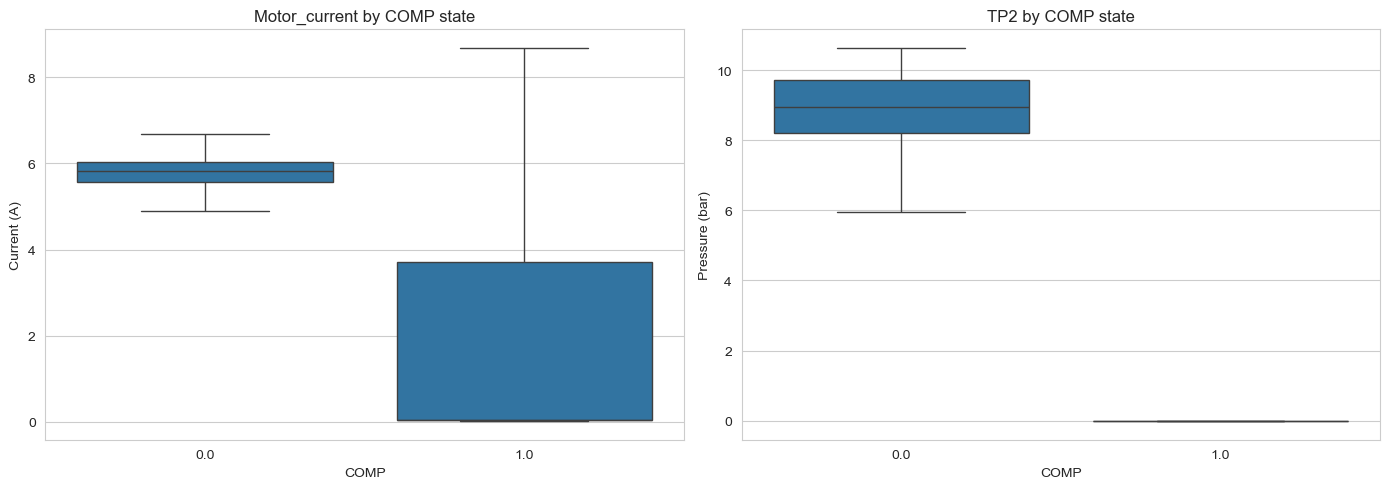

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=metro, x='COMP', y='Motor_current', ax=axes[0],
    showfliers=False
)
axes[0].set_title('Motor_current by COMP state')
axes[0].set_xlabel('COMP')
axes[0].set_ylabel('Current (A)')

sns.boxplot(
    data=metro, x='COMP', y='TP2', ax=axes[1],
    showfliers=False
)
axes[1].set_title('TP2 by COMP state')
axes[1].set_xlabel('COMP')
axes[1].set_ylabel('Pressure (bar)')

plt.tight_layout()
plt.show()

**Observations**

The `COMP` signal clearly separates two different operating regimes. Consistent with the frequency analysis in Notebook 01, the `COMP` coding appears inverted relative to its name: `COMP = 0` corresponds to active compression, while `COMP = 1` corresponds to the idle or offloaded state.

For `Motor_current`, the `COMP = 0` state is associated with a relatively narrow high-current band centered around 5-6 A, while `COMP = 1` shows a much broader distribution concentrated near zero with occasional higher values. This confirms that the two `COMP` states correspond to substantially different electrical operating conditions.

The separation is even stronger for `TP2`. When `COMP = 0`, `TP2` is concentrated in the high-pressure range (roughly 8-10 bar). When `COMP = 1`, `TP2` collapses to values near zero with negligible spread. This state-dependence explains the non-unimodal distribution observed earlier in the continuous sensor analysis, where `TP2` showed a strong mass near zero alongside a separate active operating range.

Overall, the `COMP` signal appears to be one of the strongest discrete indicators of operating regime in the MetroPT dataset.

**Grouping by `DV_eletric` signal state**

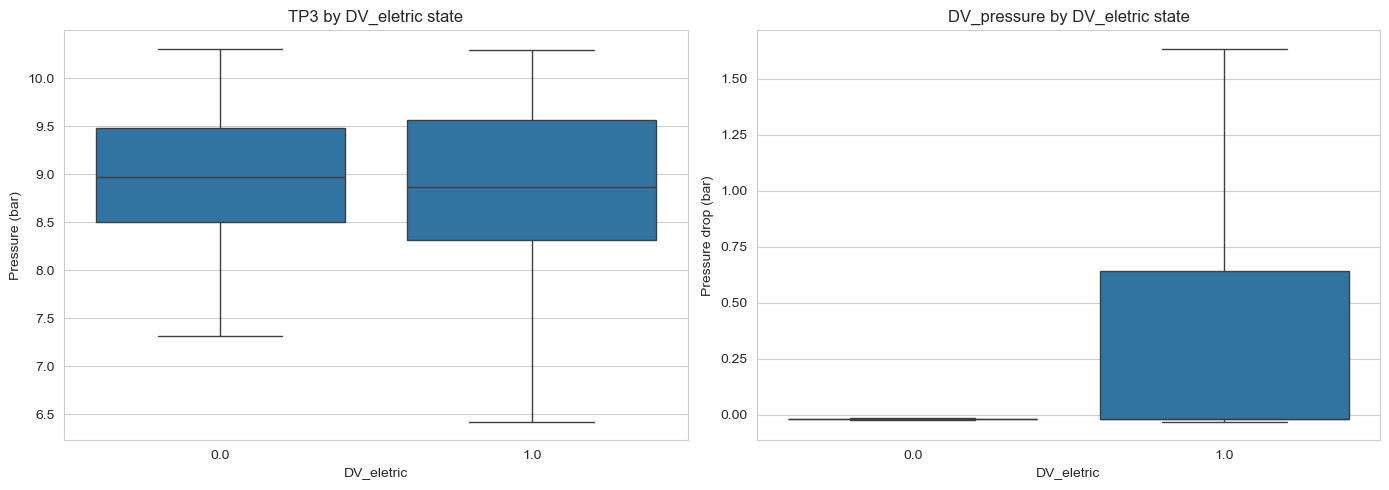

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=metro, x='DV_eletric', y='TP3', ax=axes[0],
    showfliers=False
)
axes[0].set_title('TP3 by DV_eletric state')
axes[0].set_xlabel('DV_eletric')
axes[0].set_ylabel('Pressure (bar)')

sns.boxplot(
    data=metro, x='DV_eletric', y='DV_pressure', ax=axes[1],
    showfliers=False
)
axes[1].set_title('DV_pressure by DV_eletric state')
axes[1].set_xlabel('DV_eletric')
axes[1].set_ylabel('Pressure drop (bar)')

plt.tight_layout()
plt.show()

**Observations**

The `DV_eletric` signal also separates different operating behavior, although less strongly than `COMP`.

For `TP3`, the two `DV_eletric` states overlap a lot, which suggests that downstream pressure stays relatively stable regardless of valve state. The `DV_eletric = 1` group shows a slightly wider spread and a longer lower tail, pointing to somewhat more variation in this operating mode.

The difference is much clearer for `DV_pressure`. When `DV_eletric = 0`, the pressure-drop values stay very close to zero. When `DV_eletric = 1`, the values spread much more widely, reaching above 0.5 bar with some readings close to 1.6 bar. This confirms that `DV_pressure` is closely tied to the valve-related operating mode captured by `DV_eletric`.

Overall, the `DV_eletric` signal appears to mark a more specific operating mode than `COMP`, with its strongest effect visible in the pressure-drop behavior rather than in the downstream pressure level itself.

### MetroPT-3 summary

The exploratory analysis of the MetroPT-3 dataset has characterized the continuous and binary signals from several complementary angles: distributional shape, correlation structure, temporal behavior across the monitoring period, activation rates of state and alarm signals, and the dependence of continuous sensors on discrete operating states.

Several findings are especially relevant for the subsequent analysis. The continuous sensors form interpretable groups, including a pressure-related set (`TP2`, `H1`, `DV_pressure`) and a downstream pneumatic set (`TP3`, `Reservoirs`), while `Motor_current` and `Oil_temperature` reflect the electrical and thermal behavior of the compressor system. Temporally, a visible operating-regime transition appears around early March, reflected simultaneously in `Motor_current`, `DV_eletric`, and `Caudal_impulses`. In addition, the oil-temperature baseline becomes higher in the later part of the monitoring period, while rare-event signals such as `LPS` and `Pressure_switch` show more noticeable activity toward the end of the record.

Taken together, these patterns suggest that the compressor system is not stationary across the seven-month monitoring period. Instead, the data shows evolving operating behavior, changes in activity patterns, and shifts in thermal and pressure-related response over time.

The same exploratory framework (distributions, correlations, temporal patterns, and condition-stratified comparisons), will now be applied to the hydraulic test rig dataset. This will make it possible to compare how two different fluid-power systems express state changes, variability, and potential warning patterns before moving to the final cross-dataset interpretation.

## Hydraulic System Analysis

The hydraulic dataset differs structurally from MetroPT-3. Instead of a continuous operational time series, it consists of repeated operating cycles summarized into per-cycle statistical features. The goal of the exploratory analysis is therefore to understand the distributions of these engineered features, their relationships, and how they vary across different condition states of the hydraulic system.

The structure of the hydraulic table:

In [67]:
target_cols = ['cooler_condition', 'valve_condition', 'pump_leakage', 'accumulator_pressure', 'stable_flag']
feature_cols = [col for col in hydraulics.columns if col not in target_cols]

print(f"Number of target columns: {len(target_cols)}")
print(f"Number of feature columns: {len(feature_cols)}")

selected_features = [
    'PS1_mean', 'PS1_std',
    'TS1_mean', 'TS1_std',
    'EPS1_mean', 'EPS1_std',
    'VS1_mean', 'VS1_std',
]

hydraulics[selected_features + target_cols].head()

Number of target columns: 5
Number of feature columns: 68


,PS1_mean,PS1_std,TS1_mean,TS1_std,EPS1_mean,EPS1_std,VS1_mean,VS1_std,cooler_condition,valve_condition,pump_leakage,accumulator_pressure,stable_flag
0,160.673492,13.939309,35.621983,0.308230,2538.929167,185.616121,0.576950,0.027078,3,100,0,130,1
1,160.603320,14.118967,36.676967,0.585740,2531.498900,189.940089,0.565850,0.027241,3,100,0,130,1
2,160.347720,14.192619,37.880800,0.559169,2519.928000,190.736850,0.576533,0.036729,3,100,0,130,1
3,160.188088,14.227803,38.879050,0.516176,2511.541633,191.270607,0.569267,0.033464,3,100,0,130,1
4,160.000472,14.276434,39.803917,0.535374,2503.449500,191.258369,0.577367,0.033484,3,100,0,130,1


### Feature distributions

Because the hydraulic dataset contains many engineered variables, the first step is to inspect a representative subset rather than plotting every feature at once. The selected features cover pressure, temperature, motor power, and vibration, and include both average level and within-cycle variability.

**Pressure and temperature sensors**

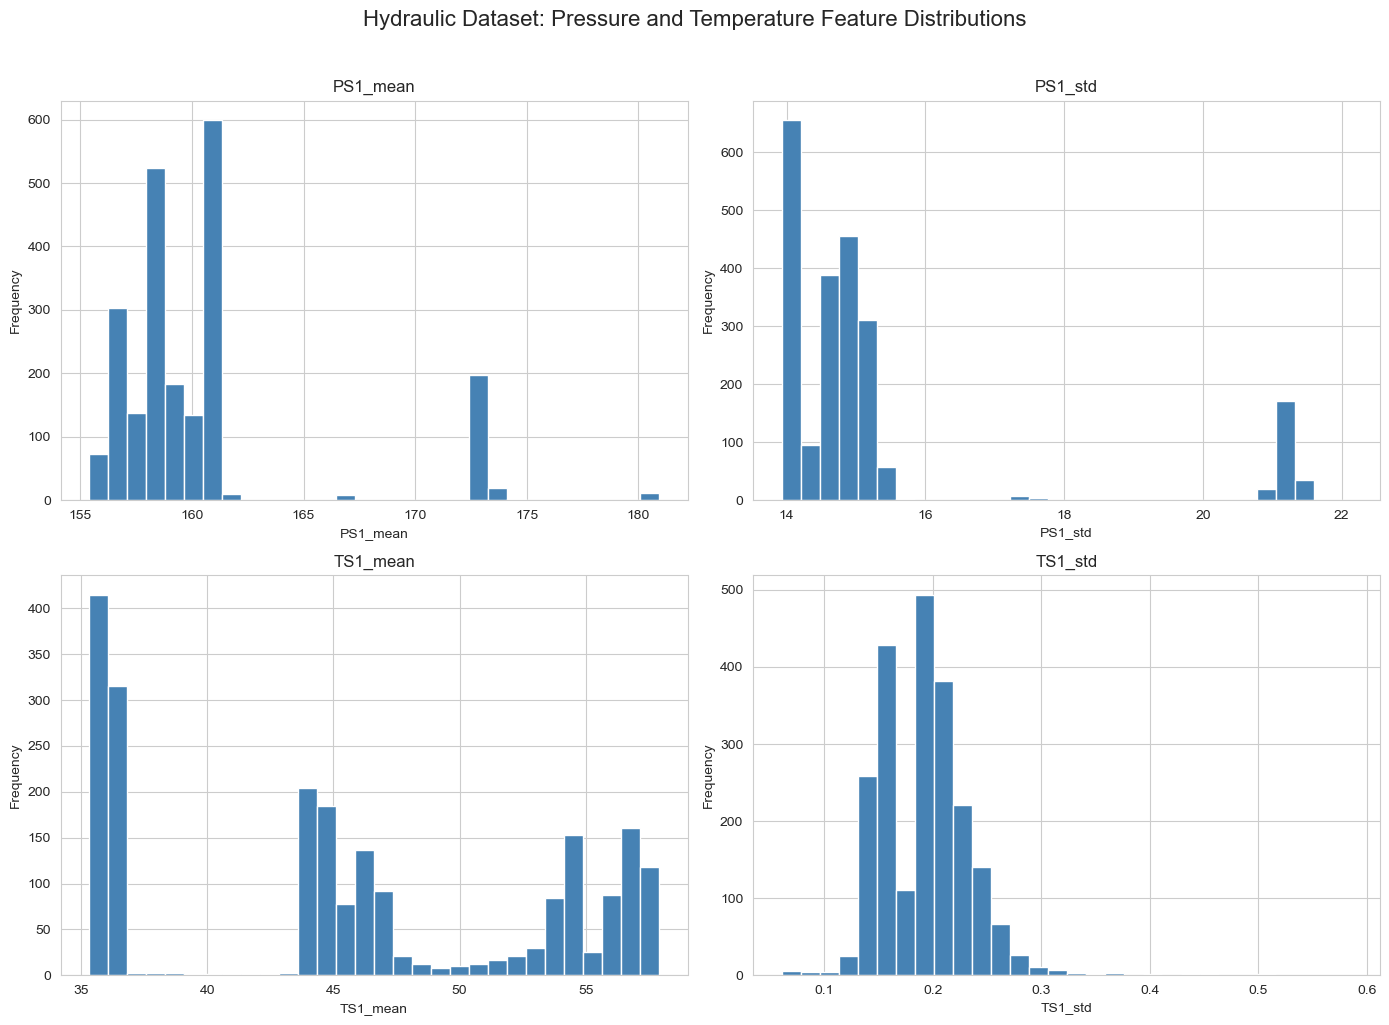

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

first_group = ['PS1_mean', 'PS1_std', 'TS1_mean', 'TS1_std']

for i, col in enumerate(first_group):
    axes[i].hist(hydraulics[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

fig.suptitle('Hydraulic Dataset: Pressure and Temperature Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Power and vibration sensors**

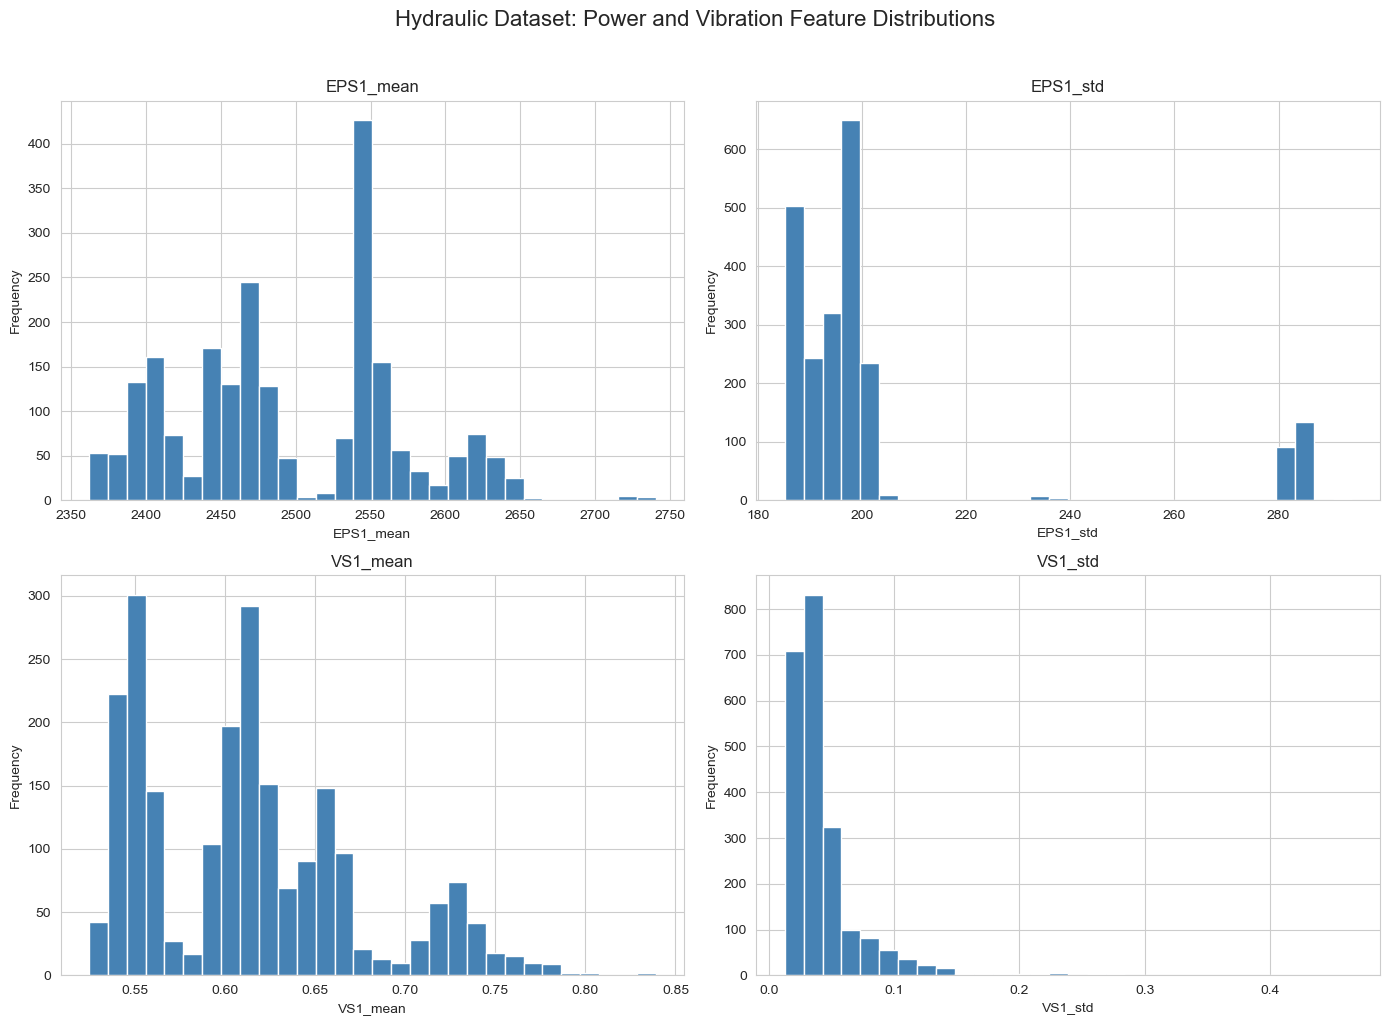

In [69]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

second_group = ['EPS1_mean', 'EPS1_std', 'VS1_mean', 'VS1_std']

for i, col in enumerate(second_group):
    axes[i].hist(hydraulics[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

fig.suptitle('Hydraulic Dataset: Power and Vibration Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Observations**

The selected hydraulic features show clear differences in distributional shape across sensor types.

The pressure features `PS1_mean` and `PS1_std` are concentrated in relatively narrow ranges, but both show visible secondary clusters and a few more extreme values. This suggests that pressure behavior is not uniform across all cycles and may vary with component condition or operating stability.

The temperature features behave differently. `TS1_mean` is clearly multi-modal, with three visible clusters around 36, 45, and 55°C rather than one smooth distribution. This indicates that the hydraulic system operates under multiple distinct thermal regimes across the recorded cycles. In contrast, `TS1_std` is more concentrated, suggesting that within-cycle temperature variability is more stable than the average temperature level itself.

The motor power features also show clustered structure, but with different shapes. `EPS1_mean` spreads broadly across approximately 2350–2750 W with several peaks, while `EPS1_std` is especially notable: most cycles show a standard deviation around 180–200 W, while a separate group of cycles is isolated near 280 W, with a visible gap between them. This pronounced bimodality suggests that the cycles may fall into two qualitatively different operating regimes rather than forming one continuous spectrum.

The vibration features are especially informative. `VS1_mean` is multi-modal, while `VS1_std` is strongly right-skewed, with most cycles showing low variability and a smaller number of cycles exhibiting much higher vibration dispersion. This makes vibration variability a plausible candidate for distinguishing abnormal or degraded operating behavior.

Overall, the feature distributions suggest that the hydraulic dataset is structurally heterogeneous across cycles. This supports the idea that the engineered features capture meaningful differences in operating condition and degradation state, rather than simple random variation around a single baseline.

### Correlation structure

After examining the distributions of selected hydraulic features, the next step is to study how these variables relate to one another. As in the MetroPT-3 analysis, correlation is used here as a first summary of linear dependence between continuous features.

Because the hydraulic dataset contains many engineered variables, the correlation analysis below focuses on the same representative subset of pressure, temperature, motor power, and vibration features used in the distribution plots.

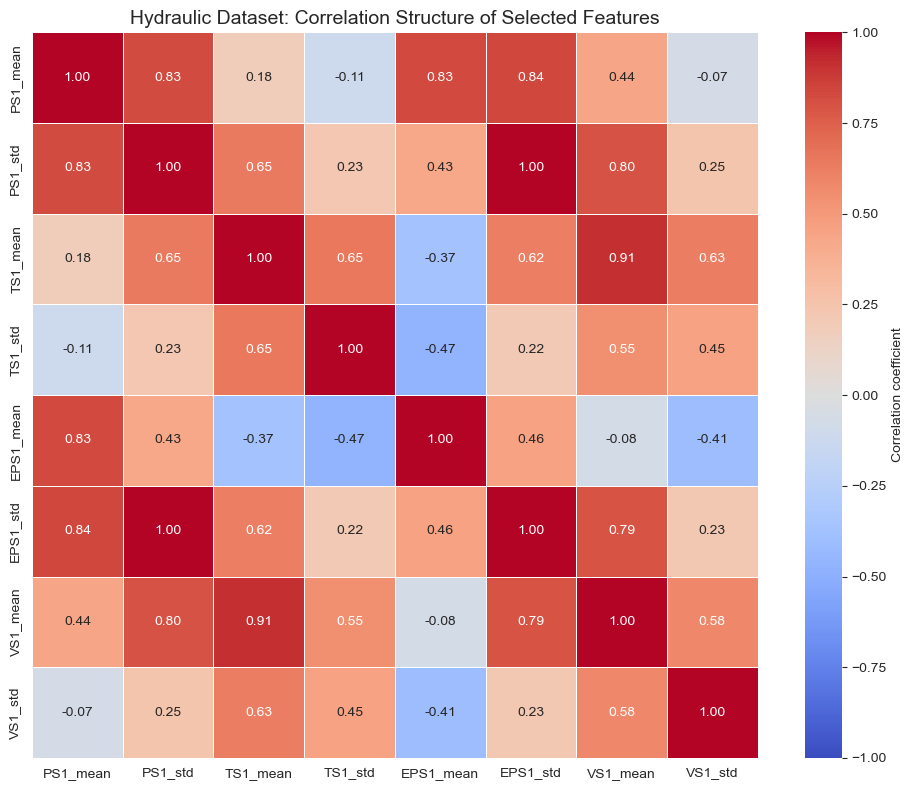

In [70]:
corr_h = hydraulics[selected_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_h,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation coefficient'},
    ax=ax
)

ax.set_title('Hydraulic Dataset: Correlation Structure of Selected Features', fontsize=14)
plt.tight_layout()
plt.show()

In [75]:
#Checking the heatmap value of PS1_std and EPS1_std at 1.00:

exact_corr = hydraulics['PS1_std'].corr(hydraulics['EPS1_std'])
print(f"PS1_std vs EPS1_std: r = {exact_corr:.10f}")

PS1_std vs EPS1_std: r = 0.9991549878


**Observations**

The correlation matrix shows that the selected hydraulic features are not independent, but form several strong and interpretable relationships across sensor families.

The strongest positive relationship appears between `TS1_mean` and `VS1_mean` ($r \approx 0.91$), suggesting that average temperature and average vibration tend to increase together across operating cycles. This indicates that these two features may reflect a shared underlying change in system condition or load regime.

Another notable result is the extremely strong positive correlation between `PS1_std` and `EPS1_std` ($r \approx 0.999$). While the two features are not identical, their within-cycle variability moves in near-perfect lockstep. This suggests that pressure variability and motor-power variability are very tightly coupled across cycles, consistent with a hydraulic system in which motor behavior is closely linked to pressure dynamics.

`PS1_mean` is also strongly positively correlated with both `EPS1_mean` and `EPS1_std` (both around $r \approx 0.83$–$0.84$), indicating that higher average pressure is associated with both higher motor power and greater power variability. In contrast, `EPS1_mean` shows moderate negative correlations with `TS1_mean`, `TS1_std`, and `VS1_std` (around $-0.37$ to $-0.47$). This suggests that electrical load captures a different dimension of cycle behavior than the thermal and vibration features, and does not simply rise with them in a uniform way.

Overall, the correlation structure supports the earlier distribution analysis: the engineered feature table captures several meaningful but distinct dimensions of cycle behavior. Some variables appear closely coupled and may contain partially overlapping information, while others contribute complementary views of hydraulic operating condition.

### Condition-stratified analysis

**Observations**

### Stable vs unstable cycles

**Observations**

### Hydraulic summary